In [31]:
import sys
sys.path.append('../')
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from utils import *  #only needed for xgboost
import xgboost as xgb
from baselines import *

In [32]:
predictor_columns = [str(i) for i in range(3, 26)]
target_column = 'estimated_volume'

In [33]:
data = pd.read_csv('datasets/stem_data.csv', index_col = [0])
data_source = data[data['Species'] == 'Pine']
data_target = data[data['Species'] == 'Spruce']
print(f'source dataset size: {len(data_source)}, target dataset size: {len(data_target)}')

data_train, data_test = train_test_split(data_target, test_size=0.1, random_state=34)

print(f'train (target) dataset size: {len(data_train)}, test (target) dataset size: {len(data_test)}')

source dataset size: 197, target dataset size: 113
train (target) dataset size: 101, test (target) dataset size: 12


In [34]:
X_source_train = np.array(data_source[predictor_columns])
y_source_train = np.array(data_source[target_column]) #change this to "Dgv" to use diameter as source label!

#Specific train and test set
X_target_train = np.array(data_train[predictor_columns])
y_target_train = np.array(data_train[target_column])

X_target_test = np.array(data_test[predictor_columns])
y_target_test = np.array(data_test[target_column])

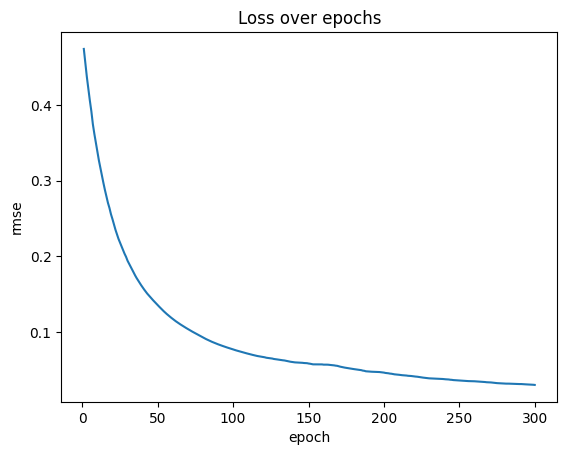

11.058270636889475


In [35]:
fiter = MTransferTreeBoost(epochs=300, k = 0.01)
fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, show_curves = True)
rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

print((rmse / np.mean(y_target_test))*100)

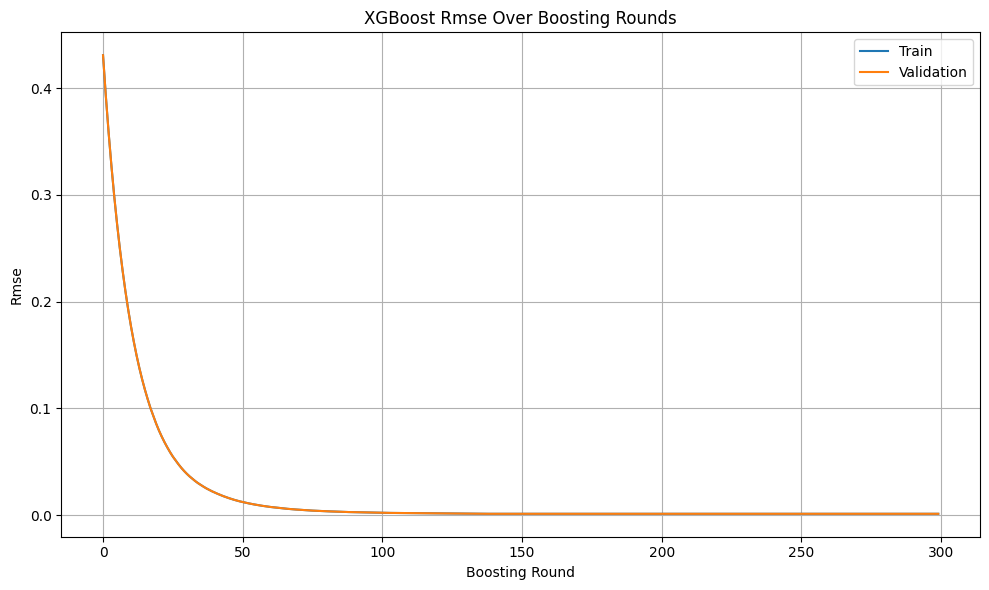

15.284157047650993


In [36]:
params = {
    'objective': 'reg:squarederror',  # Regression with squared error
    'max_depth': 6,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
    }
        
bst = train_xgboost(X_target_train, y_target_train, X_target_train, y_target_train, boosting_rounds=300, params=params, early_stopping_rounds=500, show_curve=True)
preds = test_xgboost(X_target_test, bst)
rmse = compute_rmse(preds, y_target_test)
mae = compute_mae(preds, y_target_test)

print((rmse / np.mean(y_target_test))*100)

In [37]:
import warnings
warnings.filterwarnings('ignore')
from adapt.instance_based import TrAdaBoostR2, TwoStageTrAdaBoostR2
from sklearn.metrics import mean_squared_error, mean_absolute_error
from m5py import M5Prime

from lineartree import LinearTreeRegressor
from sklearn.linear_model import LinearRegression

base_estimator = M5Prime()
model = TrAdaBoostR2(base_estimator,
                        n_estimators=30,
                        lr=1)
model.fit(X_source_train, y_source_train,
            X_target_train, y_target_train)
preds = model.predict(X_target_test)
rmse = np.sqrt(mean_squared_error(
    preds, y_target_test))
mae = mean_absolute_error(preds, y_target_test)
print((rmse / np.mean(y_target_test))*100)

Iteration 0 - Error: 0.1554
Iteration 1 - Error: 0.3182
Iteration 2 - Error: 0.4626
Iteration 3 - Error: 0.6581
Iteration 4 - Error: 0.6906
Iteration 5 - Error: 0.7337
Iteration 6 - Error: 0.7771
Iteration 7 - Error: 0.7726
Iteration 8 - Error: 0.8458
Iteration 9 - Error: 0.8670
Iteration 10 - Error: 0.8580
Iteration 11 - Error: 0.8664
Iteration 12 - Error: 0.8870
Iteration 13 - Error: 0.9002
Iteration 14 - Error: 0.8994
Iteration 15 - Error: 0.9044
Iteration 16 - Error: 0.9200
Iteration 17 - Error: 0.9220
Iteration 18 - Error: 0.9217
Iteration 19 - Error: 0.9358
Iteration 20 - Error: 0.9385
Iteration 21 - Error: 0.9353
Iteration 22 - Error: 0.9402
Iteration 23 - Error: 0.9456
Iteration 24 - Error: 0.9464
Iteration 25 - Error: 0.9517
Iteration 26 - Error: 0.9529
Iteration 27 - Error: 0.9515
Iteration 28 - Error: 0.9549
Iteration 29 - Error: 0.9585
12.398339170010447


In [38]:

# base_estimator = LinearTreeRegressor(
#     base_estimator=LinearRegression(),
#     max_depth=5,
#     min_samples_leaf=3)
base_estimator = M5Prime()
model = TwoStageTrAdaBoostR2(base_estimator,
                        n_estimators=30,
                        n_estimators_fs=30,
                        cv=10,
                        lr=1)
model.fit(X_source_train, y_source_train,
            X_target_train, y_target_train)
preds = model.predict(X_target_test)

rmse = np.sqrt(mean_squared_error(
    preds, y_target_test))
mae = mean_absolute_error(preds, y_target_test)
print((rmse / np.mean(y_target_test))*100)

Iteration 0 - Cross-validation score: 0.0678 (0.0207)


KeyboardInterrupt: 

In [ ]:
df = pd.DataFrame(columns = ['seed', 'method', 'rmse'])

for seed in range(89,99):
    data = pd.read_csv('datasets/stem_data.csv', index_col = [0])
    data_source = data[data['Species'] == 'Spruce']
    data_target = data[data['Species'] == 'Pine']
    print(f'source dataset size: {len(data_source)}, target dataset size: {len(data_target)}')

    data_temp, data_test = train_test_split(data_target, test_size=0.1, random_state=seed)
    data_train, data_val = train_test_split(data_temp, test_size=0.1, random_state=seed)

    X_source_train = np.array(data_source[predictor_columns])
    y_source_train = np.array(data_source[target_column]) #change this to "Dgv" to use diameter as source label!

    #Specific train and test set
    X_target_train = np.array(data_train[predictor_columns])
    y_target_train = np.array(data_train[target_column])

    X_target_val = np.array(data_val[predictor_columns])
    y_target_val = np.array(data_val[target_column])

    X_target_test = np.array(data_test[predictor_columns])
    y_target_test = np.array(data_test[target_column])

    fiter = MTransferTreeBoost()
    fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train, val_x=X_target_val, val_y=y_target_val, early_stopping_rounds=5, show_curves = False)
    rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
    val_rmse = fiter.evaluate(X_target_val, y_target_val, metric = 'rmse')
    mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')
    val_mae = fiter.evaluate(X_target_val, y_target_val, metric = 'mae')

    df.loc[len(df)] = [seed, 'MTransferTreeBoost', rmse]

    params = {
    'objective': 'reg:pseudohubererror',  # Regression with squared error
    'max_depth': 2,                   # Maximum depth of a tree
    'eta': 0.1,                       # Learning rate
    'eval_metric': 'rmse',           # RMSE as evaluation metric
    }
        
    bst = train_xgboost(X_target_train, y_target_train, X_target_val, y_target_val, boosting_rounds=300, params=params, early_stopping_rounds=5, show_curve=False)
    preds = test_xgboost(X_target_test, bst)
    val_preds = test_xgboost(X_target_val, bst)
    val_rmse = compute_rmse(val_preds, y_target_val)
    val_mae = compute_mae(val_preds, y_target_val)
    rmse = compute_rmse(preds, y_target_test)
    mae = compute_mae(preds, y_target_test)

    df.loc[len(df)] = [seed, 'XGBoost', rmse]


    base_estimator = M5Prime()
    model = TrAdaBoostR2(base_estimator,
                            n_estimators=30,
                            lr=1, verbose = False)
    model.fit(X_source_train, y_source_train,
                X_target_train, y_target_train)
    preds = model.predict(X_target_test)
    val_preds = model.predict(X_target_val)
    val_rmse = np.sqrt(
        mean_squared_error(val_preds, y_target_val))
    val_mae = mean_absolute_error(val_preds, y_target_val)
    rmse = np.sqrt(mean_squared_error(
        preds, y_target_test))
    mae = mean_absolute_error(preds, y_target_test)

    df.loc[len(df)] = [seed, 'TrAdaBoost.R2', rmse]

source dataset size: 113, target dataset size: 197
source dataset size: 113, target dataset size: 197
source dataset size: 113, target dataset size: 197
source dataset size: 113, target dataset size: 197
source dataset size: 113, target dataset size: 197
source dataset size: 113, target dataset size: 197
source dataset size: 113, target dataset size: 197
source dataset size: 113, target dataset size: 197
source dataset size: 113, target dataset size: 197
source dataset size: 113, target dataset size: 197


<Axes: xlabel='method', ylabel='rmse'>

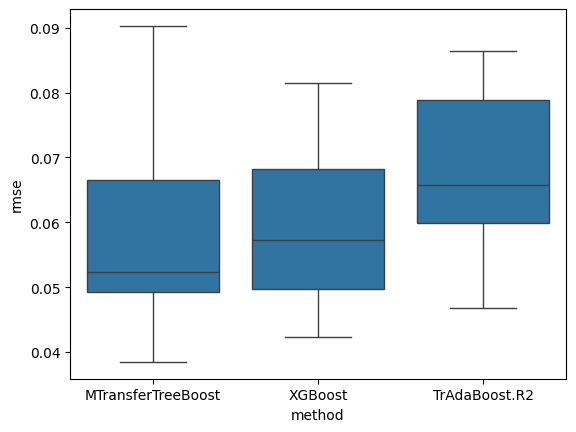

In [ ]:
import seaborn as sns
sns.boxplot(data = df, x = 'method', y = 'rmse')
